# Imports

In [ ]:
%pip install gdown

In [50]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
import nltk
import numpy as np
import matplotlib.pyplot as plt

# Setup

In [30]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /home/ediss3/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /home/ediss3/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [31]:
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

In [4]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')]


# Loading the dataset

In [39]:

# Load the dataset
file_path = 'https://raw.githubusercontent.com/Khizar-BM/ML-Mini-Project-2/main/Sentiment140.tenPercent.sample.tweets.tsv'
data = pd.read_csv(file_path, delimiter='\t', header=0, names=['sentiment_label', 'tweet_text'])

In [40]:
data.head()

,sentiment_label,tweet_text
0,4,"@elephantbird Hey dear, Happy Friday to You A..."
1,4,Ughhh layin downnnn Waiting for zeina to co...
2,0,"@greeniebach I reckon he'll play, even if he's..."
3,0,@vaLewee I know! Saw it on the news!
4,0,very sad that http://www.fabchannel.com/ has c...


We'll map the 4 labels to 1

In [42]:
data['sentiment_label'] = data['sentiment_label'].map({0: 0, 4: 1})


In [53]:
class_counts = data['sentiment_label'].value_counts()
print(class_counts)

# Calculate the percentage of each class
class_percentages = class_counts / len(data) * 100
print(class_percentages)

sentiment_label
1    80000
0    80000
Name: count, dtype: int64
sentiment_label
1    50.0
0    50.0
Name: count, dtype: float64


The dataset is perfectly balanced

In [43]:
data.head()

,sentiment_label,tweet_text
0,1,"@elephantbird Hey dear, Happy Friday to You A..."
1,1,Ughhh layin downnnn Waiting for zeina to co...
2,0,"@greeniebach I reckon he'll play, even if he's..."
3,0,@vaLewee I know! Saw it on the news!
4,0,very sad that http://www.fabchannel.com/ has c...


# Preprocessing

We use this function for preprocessing the tweets. We will be using 2 models:
1) Random Forests
2) Pre-Trained BERT

For BERT, we won't do stemming as it performs sub-word tokenization

In [41]:
# Preprocessing function to clean the tweet texts
def preprocess_text(text, stem=True):
    # Remove URLs, mentions, hashtags, HTML entities, and non-word characters
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'&\w+;', '', text)
    text = re.sub(r'\W+|\d+', ' ', text)
    text = text.lower()  # Lowercase the text

    if not stem:
        return text

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and stem the words
    tokens = [stemmer.stem(token) for token in tokens if token not in stop_words]

    return ' '.join(tokens)


In [44]:
data['preprocessed_text'] = data['tweet_text'].apply(preprocess_text)
data['preprocessed_text_rf'] = data['tweet_text'].apply(preprocess_text, stem=True)

# Random Forest

We will use TF-IDF vectorization to encode the words

In [45]:
# Split the data into features (X) and target (y)
X = data['preprocessed_text_rf']
y = data['sentiment_label'].astype(int)  # Ensure the target is of integer type

# Splitting the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Note: The following cell takes about 12 minutes to run. Please be patient :)

In [46]:
# Define a pipeline combining a TF-IDF vectorizer and a Random Forest classifier
pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Step 1: TF-IDF Vectorization
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))  # Step 2: Random Forest Classifier
])

# Train the Random Forest classifier on the training set
pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('rf', RandomForestClassifier(random_state=42))])

In [48]:

# Predict on the test set
y_pred_rf = pipeline_rf.predict(X_test)

# Evaluate the model's performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

# Output the model's accuracy and classification report
print(f"Accuracy: {accuracy_rf}")
print("Classification Report:")
print(report_rf)

Accuracy: 0.7516875
Classification Report:
{'0': {'precision': 0.7513415699488332, 'recall': 0.7524684414448194, 'f1-score': 0.7519045834894468, 'support': 16002.0}, '1': {'precision': 0.7520345561537498, 'recall': 0.7509063632954119, 'f1-score': 0.7514700362817466, 'support': 15998.0}, 'accuracy': 0.7516875, 'macro avg': {'precision': 0.7516880630512914, 'recall': 0.7516874023701157, 'f1-score': 0.7516873098855967, 'support': 32000.0}, 'weighted avg': {'precision': 0.7516880197396538, 'recall': 0.7516875, 'f1-score': 0.7516873370447972, 'support': 32000.0}}


We gt 75% test accuracy, precision and recall. The results will be visualised at the end for both models together.

# Distil BERT

We start by loading the tokenizer and the pretrained model.

In [8]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')


Initially, this model was loaded with pre-trained weights. It was then fine-tuned for the task at hand. However, fine-tuning takes a lot of time. Therefore, I have saved the fine-tuned weights and am initializing the model with those over here. You may still find the fine-tuning code below for evaluation purposes.

## Unzip trained weights

In [ ]:
import gdown

url = "https://drive.google.com/uc?export=download&id=1upUc6N_SUqIRGscCFnyLdJrULwMHf8IJ"
output = 'trained_model_weights.zip'
gdown.download(url, output, quiet=False)

In [ ]:
from zipfile import ZipFile 
  
# loading the temp.zip and creating a zip object 
with ZipFile("trained_model_weights.zip", 'r') as zObject: 
  
    # Extracting all the members of the zip  
    # into a specific location. 
    zObject.extractall( 
        path="trained_bert") 

In [19]:
model = TFDistilBertForSequenceClassification.from_pretrained('trained_bert', num_labels=2)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

## Dataset Creation

In [10]:
texts = data['preprocessed_text'].values
labels = data['sentiment_label'].values


In [11]:
train_inputs, val_inputs, train_labels, val_labels = train_test_split(texts, labels, random_state=42, test_size=0.2)


In [12]:

max_len= 128
# Tokenize and encode the sentences
X_train_encoded = tokenizer.batch_encode_plus(train_inputs.tolist(),
                                              padding=True, 
                                              truncation=True,
                                              return_token_type_ids=True,
                                              max_length = max_len,
                                              return_tensors='tf')
 
X_val_encoded = tokenizer.batch_encode_plus(val_inputs.tolist(), 
                                              padding=True, 
                                              truncation=True,
                                              return_token_type_ids=True,
                                              max_length = max_len,
                                              return_tensors='tf')

2024-02-22 17:51:52.786154: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14602 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:18:00.0, compute capability: 7.0
2024-02-22 17:51:52.787008: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 14602 MB memory:  -> device: 1, name: Tesla V100-PCIE-16GB, pci bus id: 0000:3b:00.0, compute capability: 7.0
2024-02-22 17:51:52.787653: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 14602 MB memory:  -> device: 2, name: Tesla V100-PCIE-16GB, pci bus id: 0000:86:00.0, compute capability: 7.0
2024-02-22 17:51:52.788281: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 14602 MB memory:  -> device: 3, name: Tesla V100-PCIE-16GB, pci bus id

In [14]:
# Create tf.data.Dataset
train_dataset = tf.data.Dataset.from_tensor_slices(({'input_ids': X_train_encoded['input_ids'], 'attention_mask': X_train_encoded['attention_mask']}, train_labels))
val_dataset = tf.data.Dataset.from_tensor_slices(({'input_ids': X_val_encoded['input_ids'], 'attention_mask': X_val_encoded['attention_mask']}, val_labels))

In [15]:
# Specify batch size
batch_size = 32

train_dataset = train_dataset.shuffle(len(train_inputs)).batch(batch_size)
val_dataset = val_dataset.batch(batch_size)

## Fine Tuning

Please do not run the code cells below as they take a lot of time. You may run the evaluation cells.

In [20]:
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')
model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

In [21]:
# Step 5: Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    batch_size=32,
    epochs=1
)

4000/4000 [==============================] - 637s 155ms/step - loss: 0.4097 - accuracy: 0.8133 - val_loss: 0.3783 - val_accuracy: 0.8299


In [52]:
model.save_pretrained("trained_bert")

## Evaluation

In [23]:
predictions = model.predict(val_dataset)


1000/1000 [==============================] - 40s 37ms/step


In [24]:
probabilities = tf.nn.softmax(predictions.logits, axis=-1).numpy()

In [25]:
predicted_classes = np.argmax(probabilities, axis=-1)


In [55]:
# Evaluate the model's performance
accuracy_bert = accuracy_score(val_labels, predicted_classes)
report_bert = classification_report(val_labels, predicted_classes, output_dict=True)

# Output the model's accuracy and classification report
print(f"Accuracy: {accuracy_bert}")
print("Classification Report:")
print(report_bert)

Accuracy: 0.82990625
Classification Report:
{'0': {'precision': 0.8277767430309804, 'recall': 0.8332083489563804, 'f1-score': 0.8304836650160391, 'support': 16002.0}, '1': {'precision': 0.8320644308815202, 'recall': 0.8266033254156769, 'f1-score': 0.8293248878994074, 'support': 15998.0}, 'accuracy': 0.82990625, 'macro avg': {'precision': 0.8299205869562503, 'recall': 0.8299058371860286, 'f1-score': 0.8299042764577232, 'support': 32000.0}, 'weighted avg': {'precision': 0.8299203189757596, 'recall': 0.82990625, 'f1-score': 0.8299043488812932, 'support': 32000.0}}


The model performs significantly better and achieves 83% accuracy, precision and recall after only 1 epoch of fine tuning

# Visualization

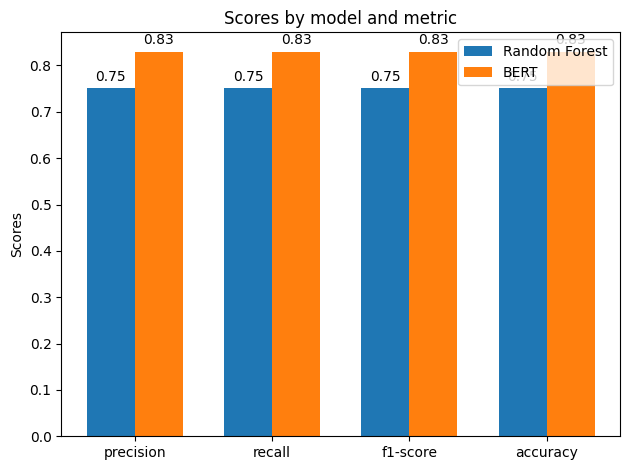

In [51]:
# Extracting macro averages for visualization
metrics = ['precision', 'recall', 'f1-score', 'accuracy']
rf_scores = [report_rf['macro avg']['precision'], report_rf['macro avg']['recall'], report_rf['macro avg']['f1-score'], report_rf['accuracy']]
bert_scores = [report_bert['macro avg']['precision'], report_bert['macro avg']['recall'], report_bert['macro avg']['f1-score'], report_bert['accuracy']]

# Setting up the bar chart
x = np.arange(len(metrics))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest')
rects2 = ax.bar(x + width/2, bert_scores, width, label='BERT')

# Adding some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('Scores by model and metric')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Function to auto-label the bars with their values
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 2)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.show()